# <center> Multi-Channel Queuing Example
## <center> Systems Engineering and Analysis
## <center> <img src="https://www.engr.colostate.edu/~jdaily/Systems-EN-CSU-1-C357.svg" width="400" /> 
### <center> Prepared by: Dr. Jeremy Daily

## A lightweight ski-lift queue model

In the last notebook, the **ticket scanner** was treated like the service bottleneck. For a ski resort, that is often not the right engineering model.

If the RFID scanner is fast, then the real bottleneck is the **quad chair leaving the terminal**. In that case, the line is controlled by:

- random skier arrivals,
- a fixed chair departure interval,
- and **4 seats per chair**.

So, instead of using a textbook M/M/c model for the scanner gates, we will simulate the lift line directly.

This version stays simple:

- no `heapq`
- no `deque`
- no `pandas`

We will only use plain Python, `numpy`, and `matplotlib`.


## How this model works

We will model the lift line like this:

- Skiers arrive according to a **Poisson process** with rate $\lambda$ skiers per second.
- A quad chair departs every $\tau$ seconds.
- Each departing chair can board up to **4 skiers**.
- The queue is the number of skiers waiting to board.

This is slightly different from a standard M/M/c queue. The four seats leave **together** as one chair, so a direct chair-departure simulation is a better fit.

The main stability check is still simple:

\[
\text{chair capacity}=\frac{\text{seats per chair}}{\text{chair interval}}
\]

For a stable line, we need

\[
\lambda < \frac{4}{\tau}
\]

We will estimate:

- average queue length, \(L_q\)
- average wait to board, \(W_q\)
- average riders per chair
- seat occupancy
- throughput


In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Example: a Colorado quad chair
# Chair interval is measured in seconds between chairs leaving the terminal.

arrival_rate = 1800 / 3600      # skiers per second (1800 skiers/hour)
chair_interval = 6.0            # seconds between chairs
seats_per_chair = 4

chair_capacity = seats_per_chair / chair_interval
utilization = arrival_rate / chair_capacity

print(f"Arrival rate        = {arrival_rate:.4f} skiers/s  ({arrival_rate*3600:.0f} skiers/hour)")
print(f"Chair capacity      = {chair_capacity:.4f} skiers/s  ({chair_capacity*3600:.0f} skiers/hour)")
print(f"Utilization         = {utilization:.4f}")

if utilization >= 1:
    print("This parameter choice is unstable because demand is at or above lift capacity.")
else:
    print("This parameter choice is stable.")

Arrival rate        = 0.5000 skiers/s  (1800 skiers/hour)
Chair capacity      = 0.6667 skiers/s  (2400 skiers/hour)
Utilization         = 0.7500
This parameter choice is stable.


## Event-driven simulation

There are only two event types:

1. **An arrival** of a skier
2. **A chair departure**

At each step, we jump directly to the next event time. That is why this method converges much faster than a tiny fixed time step.

To keep the code lightweight, we only track:

- the current queue length,
- the next arrival time,
- the next chair departure time,
- and the area under the queue-length curve.

That queue area gives us \(L_q\), and then Little's Law gives us \(W_q\).


In [3]:
def simulate_quad_chair_queue(arrival_rate,
                              chair_interval,
                              seats_per_chair=4,
                              warmup_departures=2000,
                              measured_departures=400_000,
                              seed=1,
                              checkpoints=None):
    """
    Simulate a ski-lift queue where chairs depart every chair_interval seconds
    and each chair can board up to seats_per_chair skiers.

    Arrivals follow a Poisson process with rate arrival_rate.
    """
    if arrival_rate <= 0:
        raise ValueError("arrival_rate must be positive.")
    if chair_interval <= 0:
        raise ValueError("chair_interval must be positive.")
    if seats_per_chair <= 0:
        raise ValueError("seats_per_chair must be positive.")

    chair_capacity = seats_per_chair / chair_interval
    if arrival_rate >= chair_capacity:
        raise ValueError("The queue is unstable because arrivals meet or exceed chair capacity.")

    rng = np.random.default_rng(seed)

    next_arrival = rng.exponential(1 / arrival_rate)
    next_departure = chair_interval

    queue_len = 0
    max_queue = 0
    last_event_time = 0.0

    warmup_complete = False
    total_departures_seen = 0

    measured_departures_seen = 0
    measured_start_time = None
    measured_time = 0.0
    queue_area = 0.0
    total_arrivals = 0
    total_boarded = 0
    seats_offered = 0

    checkpoints = [] if checkpoints is None else sorted(checkpoints)
    checkpoint_set = set(checkpoints)
    checkpoint_results = []

    while measured_departures_seen < measured_departures:
        if next_arrival < next_departure:
            t = next_arrival

            if warmup_complete:
                queue_area += queue_len * (t - last_event_time)

            last_event_time = t
            queue_len += 1
            max_queue = max(max_queue, queue_len)

            if warmup_complete:
                total_arrivals += 1

            next_arrival = t + rng.exponential(1 / arrival_rate)

        else:
            t = next_departure

            if warmup_complete:
                queue_area += queue_len * (t - last_event_time)

            last_event_time = t
            boarded = min(queue_len, seats_per_chair)
            queue_len -= boarded
            total_departures_seen += 1

            if not warmup_complete:
                if total_departures_seen >= warmup_departures:
                    warmup_complete = True
                    measured_start_time = t
                    last_event_time = t

                    queue_area = 0.0
                    total_arrivals = 0
                    total_boarded = 0
                    seats_offered = 0
                    measured_departures_seen = 0
            else:
                measured_departures_seen += 1
                total_boarded += boarded
                total_arrivals += 0
                seats_offered += seats_per_chair
                measured_time = t - measured_start_time

                if measured_departures_seen in checkpoint_set:
                    throughput = total_boarded / measured_time
                    Lq = queue_area / measured_time
                    Wq = queue_area / total_boarded if total_boarded > 0 else 0.0
                    checkpoint_results.append({
                        "departures": measured_departures_seen,
                        "Lq": Lq,
                        "Wq": Wq,
                        "throughput": throughput,
                    })

            next_departure += chair_interval

    throughput = total_boarded / measured_time
    effective_arrival_rate = total_arrivals / measured_time
    mean_queue_length = queue_area / measured_time
    mean_wait_to_board = queue_area / total_boarded
    mean_riders_per_chair = total_boarded / measured_departures_seen
    seat_occupancy = total_boarded / seats_offered

    return {
        "arrival_rate": arrival_rate,
        "chair_capacity": chair_capacity,
        "utilization_target": arrival_rate / chair_capacity,
        "effective_arrival_rate": effective_arrival_rate,
        "throughput": throughput,
        "Lq": mean_queue_length,
        "Wq_seconds": mean_wait_to_board,
        "Wq_minutes": mean_wait_to_board / 60.0,
        "mean_riders_per_chair": mean_riders_per_chair,
        "seat_occupancy": seat_occupancy,
        "max_queue": max_queue,
        "measured_time_seconds": measured_time,
        "measured_departures": measured_departures_seen,
        "checkpoint_results": checkpoint_results,
    }

In [4]:
results = simulate_quad_chair_queue(
    arrival_rate=arrival_rate,
    chair_interval=chair_interval,
    seats_per_chair=seats_per_chair,
    warmup_departures=2_000,
    measured_departures=400_000,
    seed=42
)

for key, value in results.items():
    if key == "checkpoint_results":
        continue
    if isinstance(value, float):
        print(f"{key:24s}: {value:.6f}")
    else:
        print(f"{key:24s}: {value}")

arrival_rate            : 0.500000
chair_capacity          : 0.666667
utilization_target      : 0.750000
effective_arrival_rate  : 0.500356
throughput              : 0.500356
Lq                      : 2.305025
Wq_seconds              : 4.606772
Wq_minutes              : 0.076780
mean_riders_per_chair   : 3.002135
seat_occupancy          : 0.750534
max_queue               : 26
measured_time_seconds   : 2400000.000000
measured_departures     : 400000


A few comments about these outputs:

- `Lq` is the **average number of skiers waiting in line**.
- `Wq_seconds` is the **average time a skier waits before boarding**.
- `mean_riders_per_chair` shows how full the chairs are on average.
- `seat_occupancy` is that same value divided by 4.
- `throughput` should settle near the arrival rate for a stable system.


In [5]:
# Little's Law check: Lq should be close to throughput * Wq

little_law_left = results["Lq"]
little_law_right = results["throughput"] * results["Wq_seconds"]

print(f"Lq from time average        = {little_law_left:.6f}")
print(f"throughput * Wq             = {little_law_right:.6f}")
print(f"absolute difference         = {abs(little_law_left - little_law_right):.6e}")

Lq from time average        = 2.305025
throughput * Wq             = 2.305025
absolute difference         = 0.000000e+00


## Convergence check

Because there is no closed-form Erlang C formula for this exact chair-departure model, a practical way to check convergence is to watch the estimates settle as the number of simulated chair departures grows.


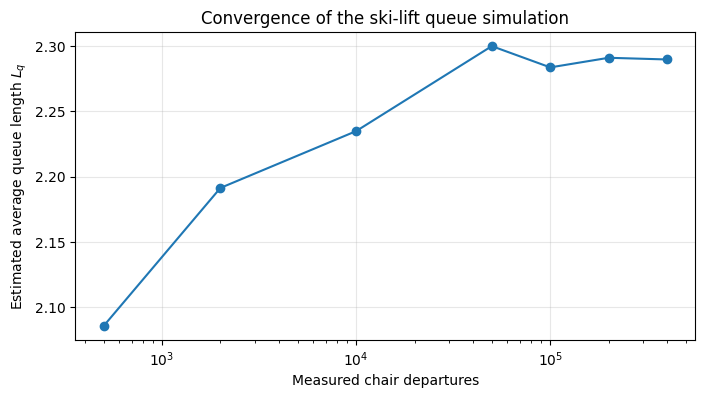

     500 departures   Lq =   2.0854   Wq =    4.242 s
   2,000 departures   Lq =   2.1912   Wq =    4.417 s
  10,000 departures   Lq =   2.2347   Wq =    4.509 s
  50,000 departures   Lq =   2.2998   Wq =    4.596 s
 100,000 departures   Lq =   2.2836   Wq =    4.563 s
 200,000 departures   Lq =   2.2909   Wq =    4.577 s
 400,000 departures   Lq =   2.2896   Wq =    4.578 s


In [6]:
checkpoints = [500, 2_000, 10_000, 50_000, 100_000, 200_000, 400_000]

conv = simulate_quad_chair_queue(
    arrival_rate=arrival_rate,
    chair_interval=chair_interval,
    seats_per_chair=seats_per_chair,
    warmup_departures=2_000,
    measured_departures=400_000,
    seed=7,
    checkpoints=checkpoints
)

deps = np.array([item["departures"] for item in conv["checkpoint_results"]], dtype=float)
Lq_vals = np.array([item["Lq"] for item in conv["checkpoint_results"]], dtype=float)
Wq_vals = np.array([item["Wq"] for item in conv["checkpoint_results"]], dtype=float)

plt.figure(figsize=(8, 4))
plt.plot(deps, Lq_vals, marker="o")
plt.xscale("log")
plt.xlabel("Measured chair departures")
plt.ylabel("Estimated average queue length $L_q$")
plt.title("Convergence of the ski-lift queue simulation")
plt.grid(True, alpha=0.3)
plt.show()

for d, Lq, Wq in zip(deps.astype(int), Lq_vals, Wq_vals):
    print(f"{d:>8,d} departures   Lq = {Lq:8.4f}   Wq = {Wq:8.3f} s")

## Replications for a confidence band

A single long run is useful, but several independent runs are even better.  
Below, we run the simulation many times and summarize the spread with a simple 95% confidence interval.


In [7]:
def run_replications(n_replications,
                     arrival_rate,
                     chair_interval,
                     seats_per_chair=4,
                     warmup_departures=2_000,
                     measured_departures=100_000,
                     seed0=100):
    Lq = np.zeros(n_replications)
    Wq = np.zeros(n_replications)
    occ = np.zeros(n_replications)

    for i in range(n_replications):
        out = simulate_quad_chair_queue(
            arrival_rate=arrival_rate,
            chair_interval=chair_interval,
            seats_per_chair=seats_per_chair,
            warmup_departures=warmup_departures,
            measured_departures=measured_departures,
            seed=seed0 + i
        )
        Lq[i] = out["Lq"]
        Wq[i] = out["Wq_seconds"]
        occ[i] = out["seat_occupancy"]

    return Lq, Wq, occ


def mean_and_ci95(x):
    mean = np.mean(x)
    s = np.std(x, ddof=1)
    half_width = 1.96 * s / math.sqrt(len(x))
    return mean, half_width

In [8]:
Lq_samples, Wq_samples, occ_samples = run_replications(
    n_replications=12,
    arrival_rate=arrival_rate,
    chair_interval=chair_interval,
    seats_per_chair=seats_per_chair,
    warmup_departures=2_000,
    measured_departures=100_000,
    seed0=500
)

Lq_mean, Lq_ci = mean_and_ci95(Lq_samples)
Wq_mean, Wq_ci = mean_and_ci95(Wq_samples)
occ_mean, occ_ci = mean_and_ci95(occ_samples)

print(f"Lq               = {Lq_mean:.4f} ± {Lq_ci:.4f}")
print(f"Wq (seconds)     = {Wq_mean:.4f} ± {Wq_ci:.4f}")
print(f"seat occupancy   = {occ_mean:.4f} ± {occ_ci:.4f}")

Lq               = 2.3058 ± 0.0093
Wq (seconds)     = 4.6082 ± 0.0132
seat occupancy   = 0.7505 ± 0.0010


## Optional design study

This last cell changes the skier arrival rate while keeping the same quad-chair spacing.  
It shows a common queueing lesson: once demand gets close to lift capacity, the average wait rises quickly.


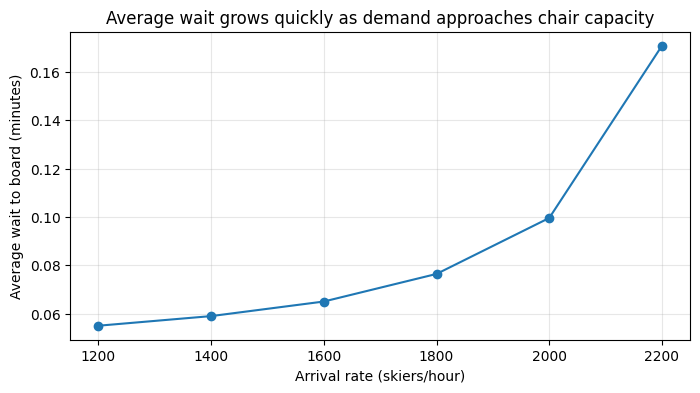

1200 skiers/hour   Lq =   1.097   Wq =   0.055 min
1400 skiers/hour   Lq =   1.372   Wq =   0.059 min
1600 skiers/hour   Lq =   1.727   Wq =   0.065 min
1800 skiers/hour   Lq =   2.288   Wq =   0.076 min
2000 skiers/hour   Lq =   3.313   Wq =   0.100 min
2200 skiers/hour   Lq =   6.257   Wq =   0.171 min


In [9]:
arrival_rates_per_hour = np.array([1200, 1400, 1600, 1800, 2000, 2200], dtype=float)

Lq_curve = []
Wq_curve = []

for lam_hr in arrival_rates_per_hour:
    lam = lam_hr / 3600.0
    out = simulate_quad_chair_queue(
        arrival_rate=lam,
        chair_interval=chair_interval,
        seats_per_chair=seats_per_chair,
        warmup_departures=2_000,
        measured_departures=100_000,
        seed=11
    )
    Lq_curve.append(out["Lq"])
    Wq_curve.append(out["Wq_minutes"])

plt.figure(figsize=(8, 4))
plt.plot(arrival_rates_per_hour, Wq_curve, marker="o")
plt.xlabel("Arrival rate (skiers/hour)")
plt.ylabel("Average wait to board (minutes)")
plt.title("Average wait grows quickly as demand approaches chair capacity")
plt.grid(True, alpha=0.3)
plt.show()

for lam_hr, Lq, Wq in zip(arrival_rates_per_hour, Lq_curve, Wq_curve):
    print(f"{lam_hr:>4.0f} skiers/hour   Lq = {Lq:7.3f}   Wq = {Wq:7.3f} min")